# This exploratory data analysis investigates the global video game market to identify key trends in publisher strategies, platform lifecycles, and shifting consumer preferences. The goal is to extract actionable business insights from historical sales data.


### DATA : https://www.kaggle.com/datasets/gregorut/videogamesales

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('vg_sales.csv')

In [3]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


## ***Data Processing***

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  object 
 1   Platform         16719 non-null  object 
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  object 
 4   Publisher        16665 non-null  object 
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  object 
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  object 
 15  Rating           9950 non-null   object 
dtypes: float64(9), object(7)
memory usage: 2.0+ MB


In [5]:
df.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
Publisher            54
NA_Sales              0
EU_Sales              0
JP_Sales              0
Other_Sales           0
Global_Sales          0
Critic_Score       8582
Critic_Count       8582
User_Score         6704
User_Count         9129
Developer          6623
Rating             6769
dtype: int64

In [6]:
df = df.dropna(subset = ['Name', 'Year_of_Release', 'Genre', 'Publisher']).copy()

In [7]:
df['Year_of_Release'] = df['Year_of_Release'].astype(int)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16416 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16416 non-null  object 
 1   Platform         16416 non-null  object 
 2   Year_of_Release  16416 non-null  int32  
 3   Genre            16416 non-null  object 
 4   Publisher        16416 non-null  object 
 5   NA_Sales         16416 non-null  float64
 6   EU_Sales         16416 non-null  float64
 7   JP_Sales         16416 non-null  float64
 8   Other_Sales      16416 non-null  float64
 9   Global_Sales     16416 non-null  float64
 10  Critic_Score     7982 non-null   float64
 11  Critic_Count     7982 non-null   float64
 12  User_Score       9837 non-null   object 
 13  User_Count       7461 non-null   float64
 14  Developer        9904 non-null   object 
 15  Rating           9767 non-null   object 
dtypes: float64(8), int32(1), object(7)
memory usage: 2.1+ MB


In [9]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
df.loc[:,'NA_Share'] = df['NA_Sales']/df['Global_Sales']

In [11]:
df.loc[:,'Era'] = df['Year_of_Release'].apply(lambda year:'Modern' if year >= 2000 else 'Retro')

In [12]:
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Share,Era
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,0.501151,Modern
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,0.722664,Retro
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,0.441441,Modern
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,0.476350,Modern
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,0.359260,Retro


In [13]:
df.nlargest(5, 'Global_Sales')

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Share,Era
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E,0.501151,Modern
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN,0.722664,Retro
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E,0.441441,Modern
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E,0.476350,Modern
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN,0.359260,Retro


In [14]:
df.nsmallest(1, 'Global_Sales')

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating,NA_Share,Era
16083,Dragon Zakura DS,DS,2007,Misc,Electronic Arts,0.0,0.0,0.01,0.0,0.01,NaN,NaN,NaN,NaN,NaN,NaN,0.0,Modern


In [15]:
df_sort = df.sort_values('Global_Sales', ascending = False)
sum_sales = df['Global_Sales'].sum()
percent = int(round(len(df_sort) * 0.01))
sum_percent_sales = df_sort[:percent]['Global_Sales'].sum()
result_percentage = sum_percent_sales / sum_sales * 100
print(f"The top 1% highest-grossing games account for {result_percentage:.1f}% of total global sales.")

The top 1% highest-grossing games account for 21.2% of total global sales.


**Key Insight:** Just **1% of the highest-grossing titles account for 21% of all global revenue**. For investors, this highlights a high-risk, high-reward environment where a single blockbuster can define a company's financial success.

## ***Plotting***

In [16]:
regional_sales = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum()
print(regional_sales)

NA_Sales       4335.94
EU_Sales       2397.29
JP_Sales       1290.67
Other_Sales     782.55
dtype: float64


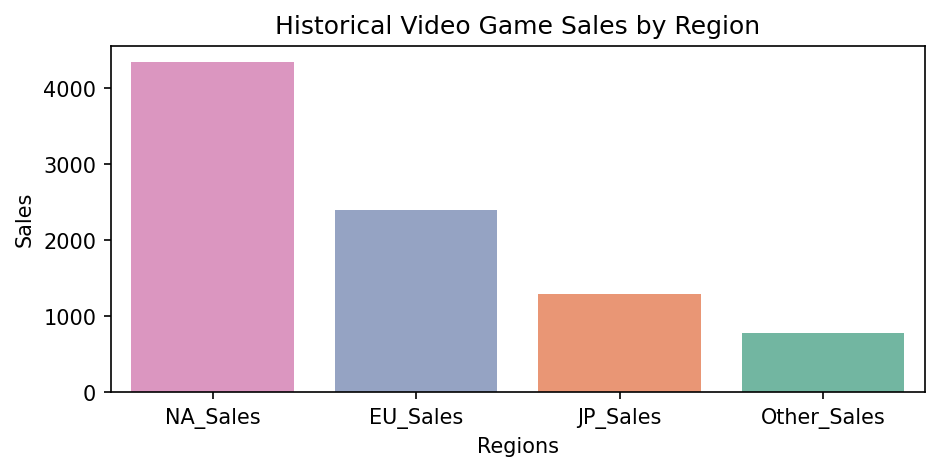

In [38]:
plt.figure(figsize = (7,3), dpi = 150)
sns.barplot(x = regional_sales.index, y = regional_sales.values, hue = regional_sales, palette = 'Set2', legend = False)
plt.xlabel('Regions')
plt.ylabel('Sales')
plt.title('Historical Video Game Sales by Region')
plt.savefig('sales_by_region.png', bbox_inches='tight', dpi = 300)
plt.show()

**Key Insight:** North America (NA) remains the dominant market leader, followed by Europe. Japan, while smaller in total volume, shows unique niche preferences that differ significantly from Western markets.

In [18]:
top_publishers = df.groupby('Publisher')['Global_Sales'].sum().nlargest(5)
top_names = top_publishers.index
df_filtered = df[df['Publisher'].isin(top_names)]
pivot = pd.pivot_table(df_filtered, index='Publisher', columns = 'Genre', aggfunc = 'sum', values = 'Global_Sales')

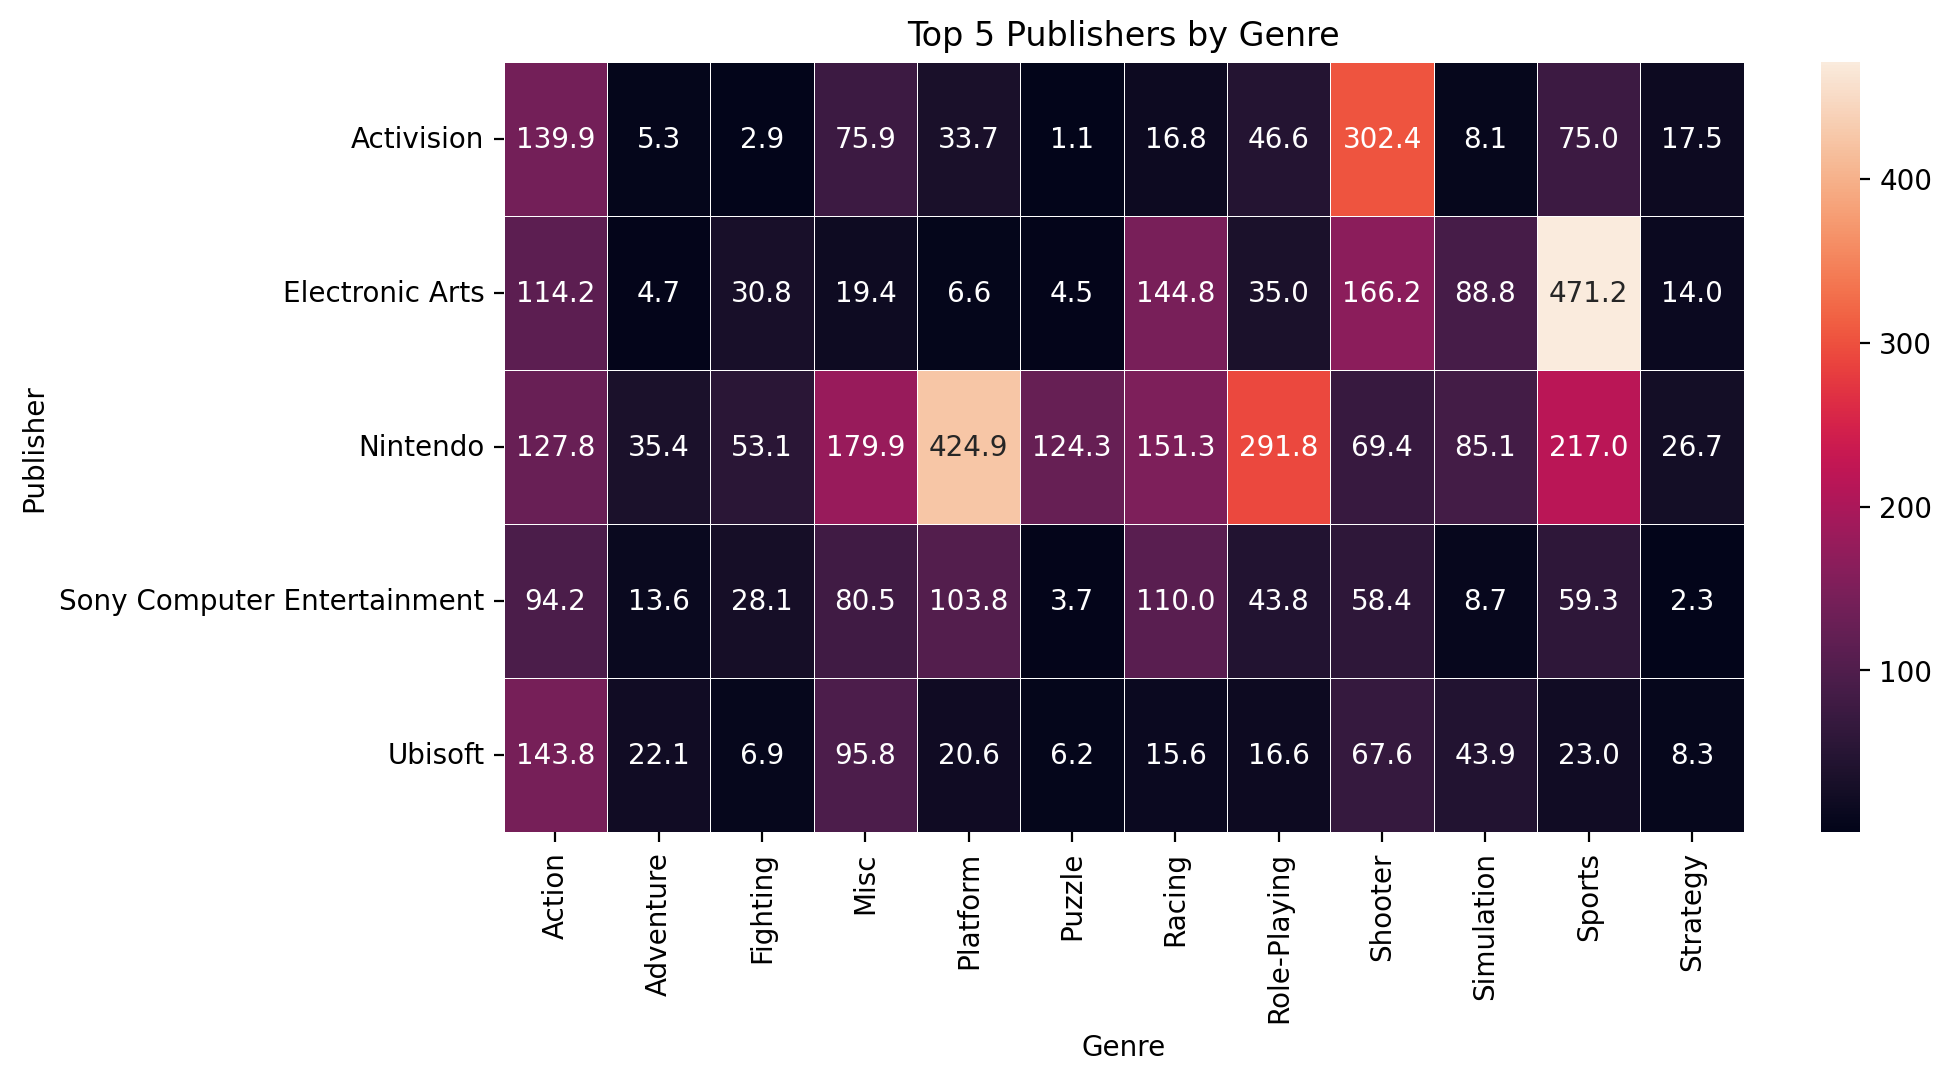

In [37]:
plt.figure(figsize = (10,5), dpi = 200)
sns.heatmap(data = pivot, annot = True, fmt='.1f', linewidth = 0.2, cmap = 'rocket')
plt.title('Top 5 Publishers by Genre')
plt.savefig('publisher_genre_heatmap.png', bbox_inches='tight', dpi = 300)
plt.show()

**Key Insight:** Different publishers use different risk strategies. **Nintendo** focuses on dominating specific niches (Platformers, Role-Playing), while **Electronic Arts (EA)** maintains a highly diversified portfolio (Sports, Action, Racing), making them more resilient to genre-specific market shifts.

In [20]:
platforms = ['PS3', 'X360', 'PC']
df_platforms = df[df['Platform'].isin(platforms)]
df_platform = df_platforms.groupby(['Year_of_Release', 'Platform'])['Global_Sales'].sum().reset_index()
df_platform.head()

,Year_of_Release,Platform,Global_Sales
0,1985,PC,0.03
1,1988,PC,0.03
2,1992,PC,3.03
3,1994,PC,12.86
4,1995,PC,4.23


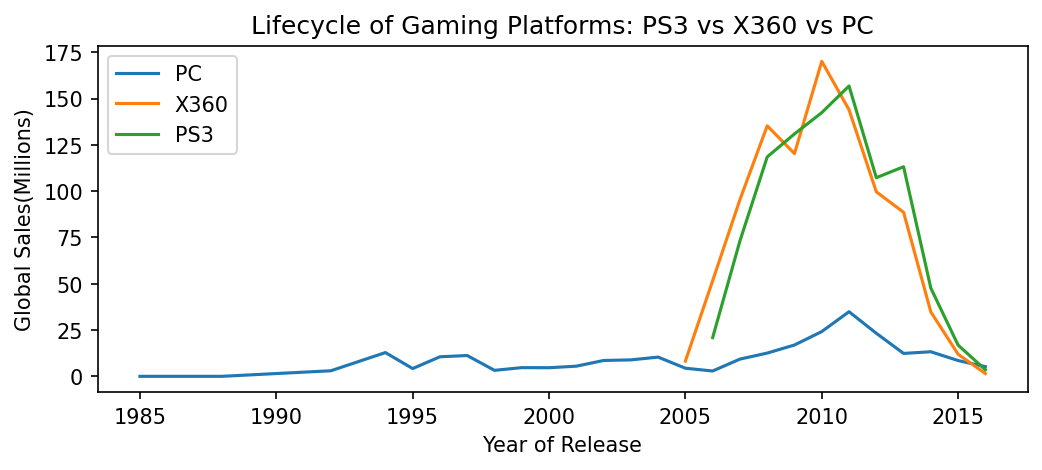

In [36]:
plt.figure(figsize = (8,3), dpi = 150)
sns.lineplot(data = df_platform, x = 'Year_of_Release', y = 'Global_Sales', hue = 'Platform')
plt.title('Lifecycle of Gaming Platforms: PS3 vs X360 vs PC')
plt.ylabel('Global Sales(Millions)')
plt.xlabel('Year of Release')
plt.legend(loc = 'upper left')
plt.savefig('platform_lifecycles.png', bbox_inches='tight', dpi = 300)
plt.show()

**Key Insight:** Consoles (PS3, X360) follow a predictable **8-10 year lifecycle** with a sharp peak and decline. In contrast, the **PC platform** demonstrates remarkable stability and long-term growth, proving to be a safer, evergreen environment for long-tail game sales.

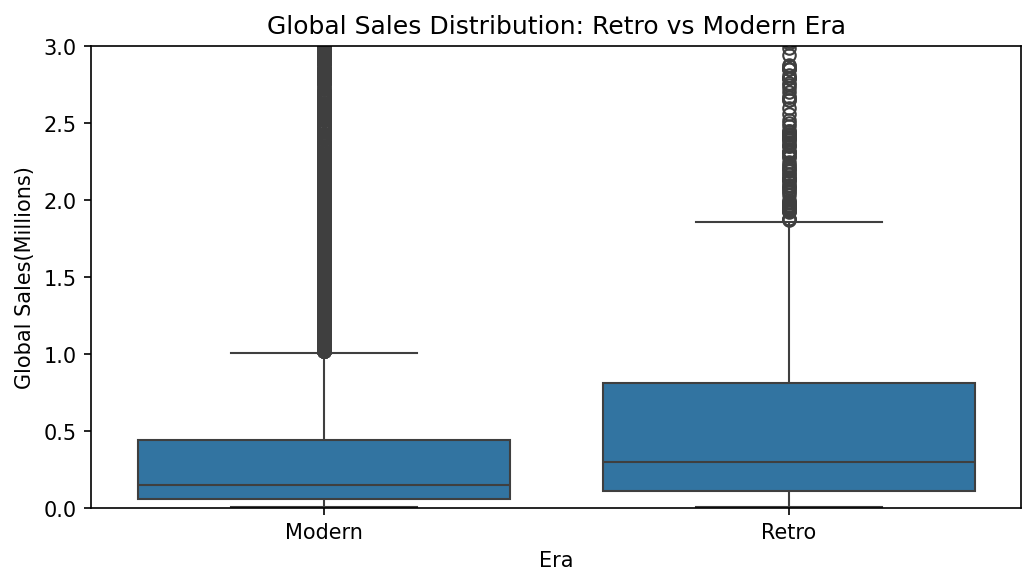

In [35]:
plt.figure(figsize = (8,4), dpi = 150)
sns.boxplot(data=df, x='Era', y='Global_Sales')
plt.title('Global Sales Distribution: Retro vs Modern Era')
plt.ylabel('Global Sales(Millions)')
plt.xlabel('Era')
plt.ylim(0, 3) 
plt.savefig('retro_vs_modern_comparison.png', bbox_inches='tight', dpi = 300)
plt.show()

**Key Insight:** The Modern market is much more saturated. While the "typical" (median) game in the Modern era earns less than its Retro counterpart, the modern era produces significantly more **financial outliers** (mega-hits), transforming the industry into a "winner-takes-all" economy.

In [23]:
genres = ['Shooter', 'Action', 'Adventure', 'Role-Playing']
df_genres = df[df['Genre'].isin(genres)].copy()
def categorize_genre(genre):
    if genre in ['Shooter', 'Action']:
        return 'Intensive'
    else:
        return 'Calm'
df_genres.loc[:,'Type'] = df_genres['Genre'].apply(categorize_genre)
df_grouped = df_genres.groupby(['Year_of_Release', 'Type'])['Global_Sales'].sum().reset_index()
df_grouped.head()

,Year_of_Release,Type,Global_Sales
0,1980,Intensive,7.41
1,1981,Intensive,24.88
2,1982,Intensive,10.31
3,1983,Calm,0.40
4,1983,Intensive,3.34


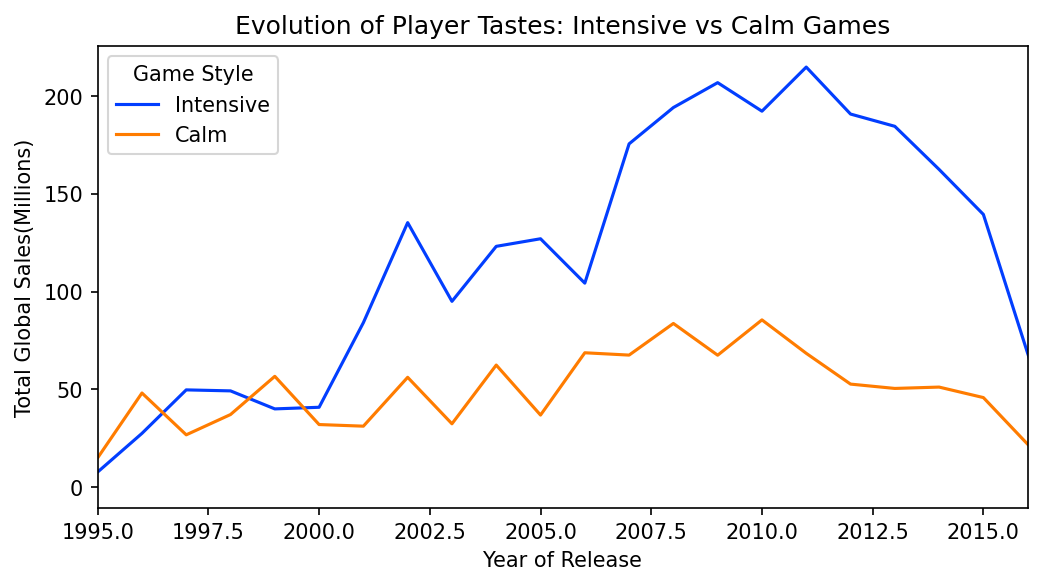

In [39]:
plt.figure(figsize=(8,4), dpi = 150)
sns.lineplot(data = df_grouped, x = 'Year_of_Release', y = 'Global_Sales', hue = 'Type', palette = 'bright')
plt.title('Evolution of Player Tastes: Intensive vs Calm Games')
plt.xlabel('Year of Release')
plt.ylabel('Total Global Sales(Millions)')
plt.legend(title='Game Style')
plt.xlim(1995, 2016)
plt.savefig('player_tastes_evolution.png', bbox_inches='tight', dpi = 300)
plt.show()

**Key Insight:** While **Intensive games** are the primary drivers of global mass-market revenue, **Calm/Story-driven games** maintain a stable and loyal audience. There is a noticeable trend where story-rich projects are becoming a vital "prestige" segment of the market.

## Final Executive Summary
1. **Monopoly is Real:** 1% of titles control 21% of the cash. Success in gaming requires "aiming for the moon."
2. **Platform Strategy:** PC is the most stable investment, while consoles require perfect timing within their 8-year cycles.
3. **Diversification Matters:** Publishers like EA show that a broad genre portfolio is key to long-term market leadership.
4. **Market Saturation:** It is harder for an average game to succeed today than in the 90s, but the ceiling for "hits" has reached unprecedented heights.
5. **Bonus Fun Fact:** The #1 game in our list (Wii Sports) has double the sales of the runner-up. This isn't just because it was popular, but because Nintendo bundled it for free with the console. It's a great example of how business strategy can create massive "outliers" in data.